In [1]:
import random
import math
from collections import defaultdict

customers = [(1, 1), (2, 4), (3, 2), (6, 6)]
facilities = [(1, 3), (3, 3), (5, 1), (7, 5), (6, 2)]
p = 3
Degprt = 0.33
NR = NA = max(1, int(p * Degprt))

def distance(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def compute_adjacency(solution):
    counts = defaultdict(int)
    open_facilities = [i for i, bit in enumerate(solution) if bit == 1]
    for cust in customers:
        best_fac = min(open_facilities, key=lambda idx: distance(cust, facilities[idx]))
        counts[best_fac] += 1
    return counts

def random_solution():
    s = [0] * len(facilities)
    for i in random.sample(range(len(facilities)), p):
        s[i] = 1
    return s
#LH1 Random Remove + Greedy addition
def LLH1(solution):
    s = solution.copy()
    open_idx = [i for i, v in enumerate(s) if v == 1]
    remove = random.sample(open_idx, NR)
    for i in remove:
        s[i] = 0
    while sum(s) < p:
        closed = [i for i, v in enumerate(s) if v == 0]
        best = max(closed, key=lambda idx: sum(1 for cust in customers if idx == min([j for j in range(len(facilities)) if s[j] == 1 or j == idx], key=lambda j: distance(cust, facilities[j]))))
        s[best] = 1
    return s
#LH2 Greedy Add + Random Remove
def LLH2(solution):
    s = solution.copy()
    closed = [i for i, v in enumerate(s) if v == 0]
    to_add = random.sample(closed, NA)
    for i in to_add:
        s[i] = 1
    while sum(s) > p:
        adjacency = compute_adjacency(s)
        to_remove = min([i for i, v in enumerate(s) if v == 1], key=lambda idx: adjacency.get(idx, 0))
        s[to_remove] = 0
    return s
#LH3 Greedy remove and Addition
def LLH3(solution):
    s = solution.copy()
    for _ in range(NR):
        adjacency = compute_adjacency(s)
        to_remove = min([i for i, v in enumerate(s) if v == 1], key=lambda idx: adjacency.get(idx, 0))
        s[to_remove] = 0
    while sum(s) < p:
        closed = [i for i, v in enumerate(s) if v == 0]
        best = max(closed, key=lambda idx: sum(1 for cust in customers if idx == min([j for j in range(len(facilities)) if s[j] == 1 or j == idx], key=lambda j: distance(cust, facilities[j]))))
        s[best] = 1
    return s
#Random Remove and Add
def LLH4(solution):
    s = solution.copy()
    while sum(s) < p + NA:
        closed = [i for i, v in enumerate(s) if v == 0]
        best = max(closed, key=lambda idx: sum(1 for cust in customers if idx == min([j for j in range(len(facilities)) if s[j] == 1 or j == idx], key=lambda j: distance(cust, facilities[j]))))
        s[best] = 1
    while sum(s) > p:
        adjacency = compute_adjacency(s)
        to_remove = min([i for i, v in enumerate(s) if v == 1], key=lambda idx: adjacency.get(idx, 0))
        s[to_remove] = 0
    return s

def evaluate(solution):
    open_facilities = [facilities[i] for i, bit in enumerate(solution) if bit == 1]
    return sum(min(distance(c, f) for f in open_facilities) for c in customers)

#Results
initial = random_solution()
print("Initial:", initial, "Cost:", evaluate(initial))
for i, llh in enumerate([LLH1, LLH2, LLH3, LLH4], start=1):
    modified = llh(initial)
    print(f"LH{i}:", modified, "Cost:", evaluate(modified))


Initial: [1, 0, 1, 1, 0] Cost: 7.06449510224598
LH1: [1, 1, 1, 0, 0] Cost: 8.65685424949238
LH2: [1, 1, 0, 1, 0] Cost: 5.82842712474619
LH3: [1, 1, 0, 1, 0] Cost: 5.82842712474619
LH4: [1, 1, 0, 1, 0] Cost: 5.82842712474619


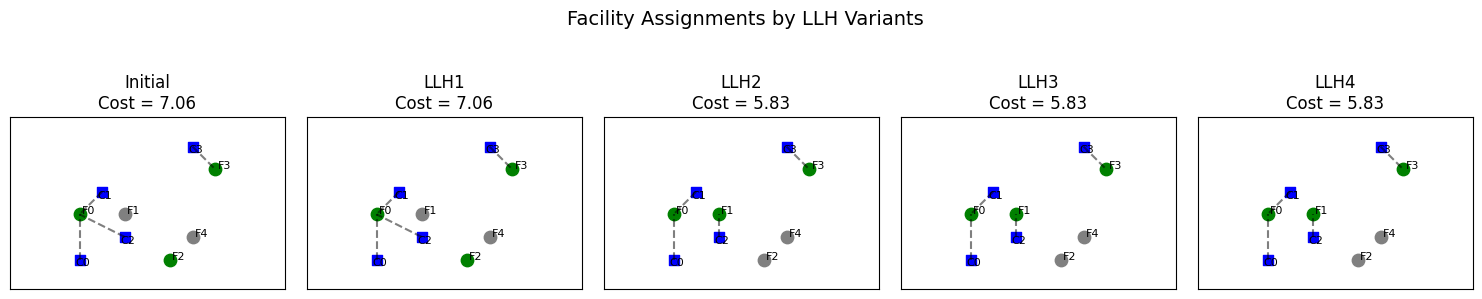

In [2]:
import matplotlib.pyplot as plt
import math

titles = ["Initial", "LLH1", "LLH2", "LLH3", "LLH4"]
solutions = [initial, LLH1(initial), LLH2(initial), LLH3(initial), LLH4(initial)]

def distance(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def evaluate(solution):
    open_facilities = [facilities[i] for i, bit in enumerate(solution) if bit == 1]
    return sum(min(distance(c, f) for f in open_facilities) for c in customers)

plt.figure(figsize=(15, 3))

for idx, sol in enumerate(solutions):
    plt.subplot(1, 5, idx + 1)

   
    for i, (x, y) in enumerate(customers):
        plt.scatter(x, y, color='blue', marker='s', s=60)
        plt.text(x - 0.2, y - 0.3, f"C{i}", fontsize=8)
    # 
    for i, (x, y) in enumerate(facilities):
        color = 'green' if sol[i] == 1 else 'gray'
        plt.scatter(x, y, color=color, s=80, marker='o')
        plt.text(x + 0.1, y, f"F{i}", fontsize=8)

    open_facilities = [facilities[i] for i, bit in enumerate(sol) if bit == 1]
    for cust in customers:
        best_fac = min(open_facilities, key=lambda f: distance(cust, f))
        plt.plot([cust[0], best_fac[0]], [cust[1], best_fac[1]], 'k--', alpha=0.5)

    plt.title(f"{titles[idx]}\nCost = {evaluate(sol):.2f}")
    plt.axis('equal')
    plt.xticks([])
    plt.yticks([])
    plt.grid(True)

plt.suptitle("Facility Assignments by LLH Variants", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Additional imports (keep previous imports)
import random
import math
from collections import defaultdict
import numpy as np

# --- Previous problem setup and functions remain the same ---
# (Keep all your existing code for distance, compute_adjacency, 
#  random_solution, evaluate, local_search, and the LLH functions)

# Define LLH names and functions
LLH_names = ['LH1', 'LH2', 'LH3', 'LH4']
LLH_functions = [LH1, LH2, LH3, LH4]

def generate_dt_training_data(samples=100):
    """Generate training data for decision tree"""
    rows = []
    for _ in range(samples):
        base = generate_initial_solution()
        base_cost = evaluate(base)
        
        # Get performance of each LLH
        llh_performance = []
        for llh in LLH_functions:
            modified = llh(base, random.uniform(Min_prt, Max_prt))
            mod_cost = evaluate(modified)
            improvement = base_cost - mod_cost
            llh_performance.append(improvement)
        
        # Find best performing LLH
        best_llh = np.argmax(llh_performance)
        
        # Create features
        adjacency = compute_adjacency(base)
        num_open = sum(base)
        coverage = sum(adjacency.values()) / len(customers)
        features = {
            'num_open': num_open,
            'coverage': coverage,
            'cost': base_cost,
            'best_llh': best_llh
        }
        
        # Add adjacency counts as features
        for i in range(len(facilities)):
            features[f'adj_{i}'] = adjacency.get(i, 0)
        
        rows.append(features)
    
    return pd.DataFrame(rows)

# Generate training data
df = generate_dt_training_data(500)

# Prepare features and target
feature_cols = ['num_open', 'coverage', 'cost'] + [f'adj_{i}' for i in range(len(facilities))]
X = df[feature_cols]
y = df['best_llh']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train decision tree
dtree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    random_state=42
)
dtree.fit(X_train, y_train)

# Evaluate
y_pred = dtree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=LLH_names)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)

# Visualize the tree
plt.figure(figsize=(20,10))
plot_tree(dtree, 
          feature_names=feature_cols,
          class_names=LLH_names,
          filled=True,
          rounded=True)
plt.show()

# Modified greedy hyperheuristic with Decision Tree
def dt_hyperheuristic():
    X_best = None
    best_cost = float('inf')
    
    # Outer loop
    while True:  # Replace with actual termination condition
        X_init = generate_initial_solution()
        X_tr = X_init
        
        # Training phase (same as before)
        for iter_tr in range(1, Max_tr + 1):
            Deg_prt = ((Max_prt - Min_prt) / Max_tr) * (Max_tr - iter_tr) + Min_prt
            
            X1 = LH1(X_tr, Deg_prt)
            X2 = LH2(X_tr, Deg_prt)
            X3 = LH3(X_tr, Deg_prt)
            X4 = LH4(X_tr, Deg_prt)
            
            solutions = [X1, X2, X3, X4]
            costs = [evaluate(sol) for sol in solutions]
            X_tr = solutions[np.argmin(costs)]
            
            current_cost = min(costs)
            if current_cost < best_cost:
                X_best = X_tr
                best_cost = current_cost
        
        # Testing phase with Decision Tree
        X_test = X_tr
        for iter_test in range(1, Max_test + 1):
            # Extract features for current solution
            adjacency = compute_adjacency(X_test)
            features = {
                'num_open': sum(X_test),
                'coverage': sum(adjacency.values()) / len(customers),
                'cost': evaluate(X_test)
            }
            for i in range(len(facilities)):
                features[f'adj_{i}'] = adjacency.get(i, 0)
            
            # Convert to DataFrame for prediction
            X_input = pd.DataFrame([features])[feature_cols]
            
            # Predict best LLH
            best_llh = dtree.predict(X_input)[0]
            Deg_prt = ((Max_prt - Min_prt) / Max_test) * (Max_test - iter_test) + Min_prt
            
            # Apply the selected LLH
            modified = LLH_functions[best_llh](X_test, Deg_prt)
            modified = local_search(modified)
            
            current_cost = evaluate(modified)
            if current_cost < best_cost:
                X_best = modified
                best_cost = current_cost
            
            X_test = modified
        
        # Final local search
        X_best = local_search(X_best)
        
        return X_best

# Run the DT hyperheuristic
best_solution = dt_hyperheuristic()
print("\nBest solution found:", best_solution)
print("Best cost:", evaluate(best_solution))

NameError: name 'LH1' is not defined